<a href="https://colab.research.google.com/github/gabrielxbox/Formacao_Completa_Intelig-ncia_Artificial/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np

In [18]:
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input

In [19]:
(X_train, _), (X_test, _) = mnist.load_data()

In [20]:
X_train.shape

(60000, 28, 28)

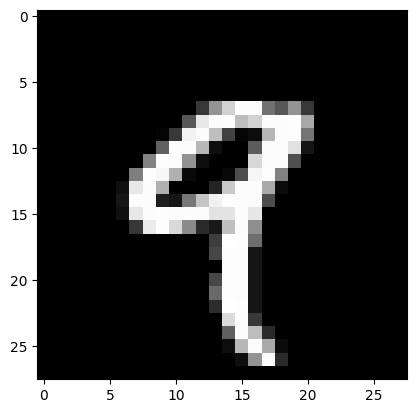

In [21]:
plt.imshow(X_train[4], cmap="gray")

In [22]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [23]:
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

normalização dos dados

In [24]:
X_train_noisy = X_train + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

In [25]:
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0)

In [26]:
inputs = Input(shape=(784,))
encoder = Dense(32, activation="relu")(inputs)
decoder = Dense(784, activation="sigmoid")(encoder)
autoencoder = Model(inputs=inputs, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.fit(X_train_noisy, X_train, epochs=100, batch_size=256, shuffle=True,
                validation_data=(X_test_noisy, X_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2816 - val_loss: 0.2173
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1968 - val_loss: 0.1814
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1747 - val_loss: 0.1661
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1612 - val_loss: 0.1535
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1499 - val_loss: 0.1450
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1437 - val_loss: 0.1400
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1393 - val_loss: 0.1362
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1359 - val_loss: 0.1331
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1333 - val_loss: 0.1314
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1319 - val_loss: 0.1305
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1310 - val_loss: 0.1297
Epoch 12/100
235/235 ━━━━━━━━━

In [27]:
idx = np.random.randint(0, X_test.shape[0])
original_image = X_test[idx]
noisy_image = original_image + 0.5 * np.random.normal(loc=0.0, scale=10, size=original_image.shape)
noisy_image = np.clip(noisy_image, 0.0, 1.0)

denoised_image = autoencoder.predict(np.expand_dims(noisy_image, axis=0))
denoised_image = denoised_image.reshape(28,28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


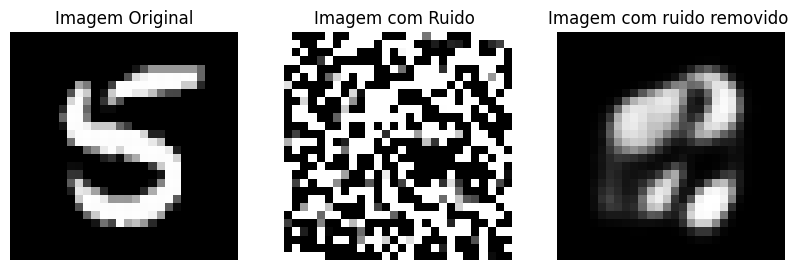

In [28]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 3, 1)
plt.imshow(original_image.reshape(28, 28), cmap="gray")
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_image.reshape(28, 28), cmap="gray")
plt.title("Imagem com Ruido ")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised_image, cmap="gray")
plt.title("Imagem com ruido removido ")
plt.axis("off")
plt.show()